# Import Libraries

In [38]:
import numpy as np
import pylidc as pl
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from sqlalchemy import and_
from tabulate import tabulate
from pylidc.utils import consensus
from skimage.measure import find_contours
import math
import pandas as pd
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import os
from contextlib import redirect_stdout


In [ ]:
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

# Explore NBIA Digest Data (XLSX)

## Load Data

In [4]:
nbia_digest_df = pd.read_excel("../../dataset_sample/lidc_idri_metadata/TCIA_LIDC-IDRI_20200921-nbia-digest.xlsx")
nbia_digest_df.columns = (
    nbia_digest_df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
nbia_digest_df.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(nbia_digest_df.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               1308 non-null   object 
 1   patient_name                             0 non-null      float64
 2   patient_birth_date                       0 non-null      float64
 3   patient_sex                              451 non-null    object 
 4   ethnic_group                             61 non-null     object 
 5   phantom                                  1308 non-null   object 
 6   species_code                             1308 non-null   int64  
 7   species_description                      1308 non-null   object 
 8   study_instance_uid                       1308 non-null   object 
 9   study_date                               1308 non-null

,patient_id,patient_name,patient_birth_date,patient_sex,ethnic_group,phantom,species_code,species_description,study_instance_uid,study_date,...,manufacturer_model_name,software_versions,image_count,max_submission_timestamp,license_name,license_uri,collection_uri,file_size,date_released,third_party_analysis
0,LIDC-IDRI-0001,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,2000-01-01 00:00:00.0,...,Revolution XQi ADS_28.2,Ads Application Package VERSION ADS_28.2,2,2020-02-21 15:12:42.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,16357620,2020-02-21 15:12:42.0,NaN
1,LIDC-IDRI-0001,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,2000-01-01 00:00:00.0,...,LightSpeed Plus,LightSpeedApps2.4.2_H2.4M5,133,2020-02-21 15:12:49.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,70018838,2020-02-21 15:12:49.0,NaN
2,LIDC-IDRI-0002,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,2000-01-01 00:00:00.0,...,Revolution XRd ADS_27.5.4,Ads Application Package VERSION ADS_27.5.4,1,2020-02-21 15:12:48.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,6909958,2020-02-21 15:12:48.0,NaN
3,LIDC-IDRI-0002,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,2000-01-01 00:00:00.0,...,LightSpeed16,06MW03.5,261,2020-02-21 15:13:03.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,137396696,2020-02-21 15:13:03.0,NaN
4,LIDC-IDRI-0003,NaN,NaN,NaN,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,2000-01-01 00:00:00.0,...,LightSpeed16,06MW03.5,140,2020-02-21 15:13:11.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,73704090,2020-02-21 15:13:11.0,NaN


## EDA Dashboard

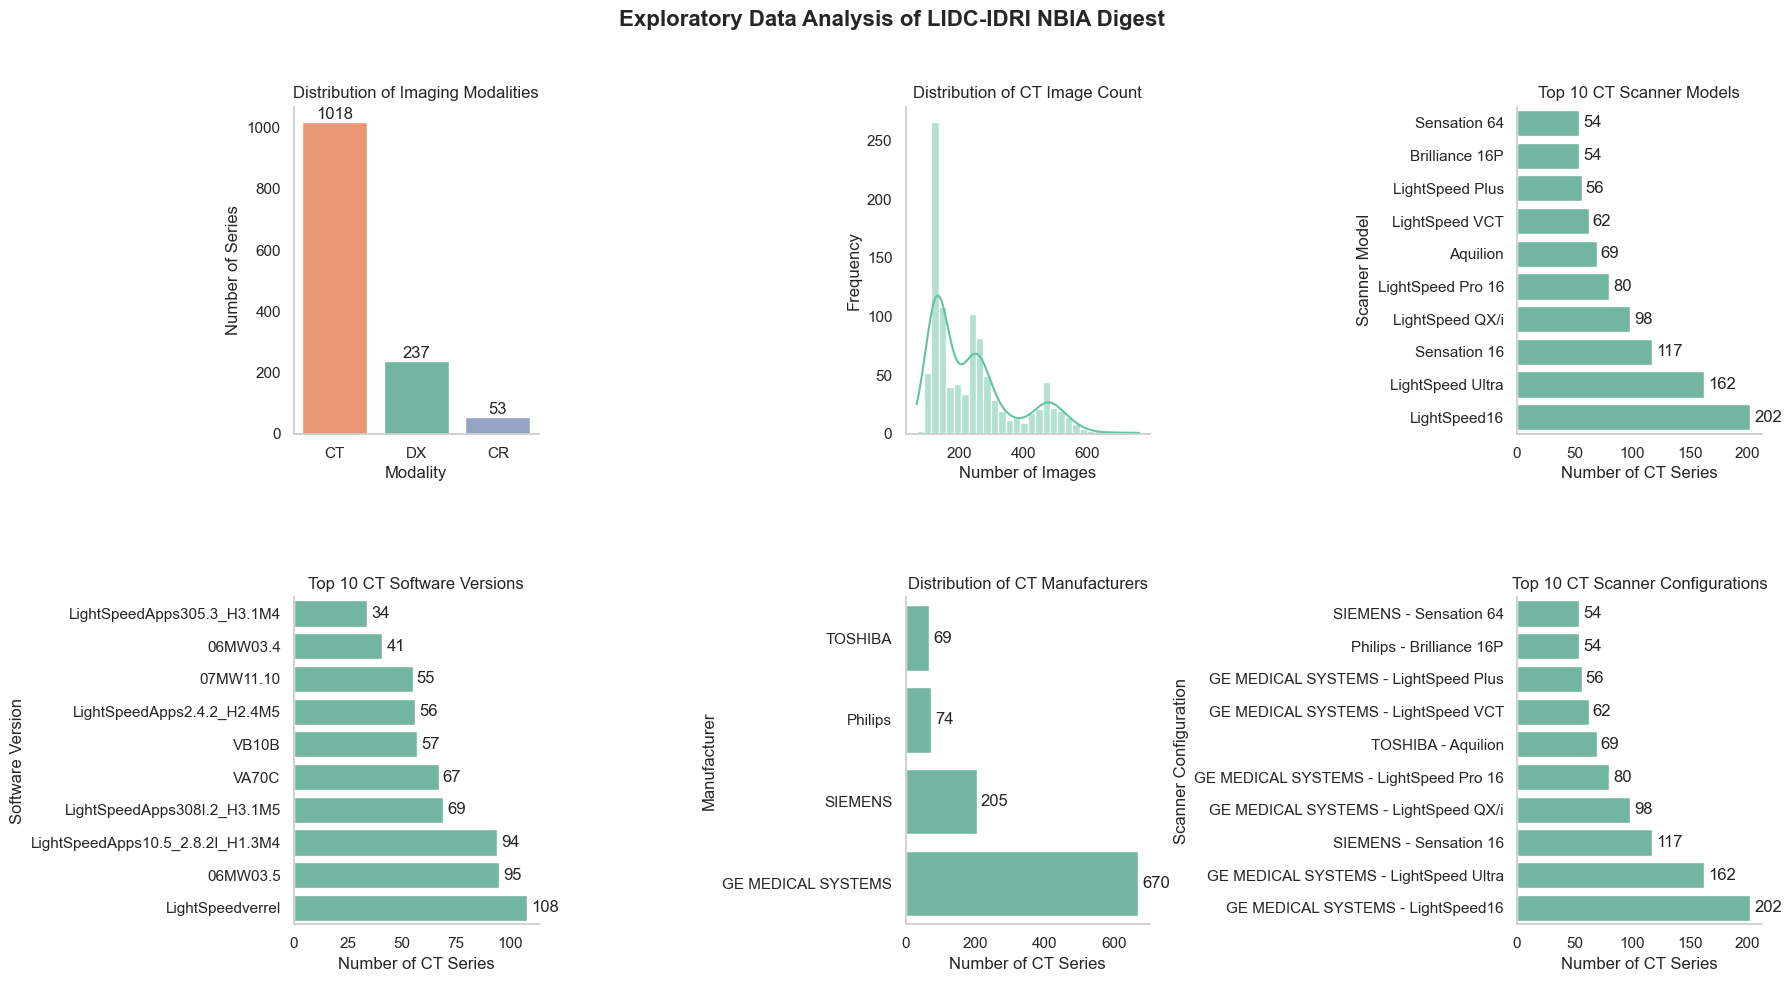

In [5]:
# Filter CT only
ct_df = nbia_digest_df[nbia_digest_df["modality"] == "CT"].copy()

# Dashboard Layout
n_charts = 6
n_cols = 3
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

fig.suptitle(
    "Exploratory Data Analysis of LIDC-IDRI NBIA Digest",
    fontsize=16,
    fontweight="bold"
)

axes = axes.flatten()

# Imaging Modalities
ax = axes[0]

sns.countplot(
    data=nbia_digest_df,
    x="modality",
    hue="modality",
    order=nbia_digest_df["modality"].value_counts().index,
    legend=False,
    ax=ax
)

ax.set_title("Distribution of Imaging Modalities")
ax.set_xlabel("Modality")
ax.set_ylabel("Number of Series")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(ax=ax)

# CT Manufacturers
ax = axes[4]

manufacturer_counts = (
    ct_df["manufacturer"]
    .value_counts()
    .sort_values()
)

sns.barplot(
    x=manufacturer_counts.values,
    y=manufacturer_counts.index,
    ax=ax
)

ax.set_title("Distribution of CT Manufacturers")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Manufacturer")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Top 10 CT Scanner Models
ax = axes[2]

scanner_model_counts = (
    ct_df["manufacturer_model_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=scanner_model_counts.values,
    y=scanner_model_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Scanner Models")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Scanner Model")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Top 10 CT Software Versions
ax = axes[3]

software_counts = (
    ct_df["software_versions"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=software_counts.values,
    y=software_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Software Versions")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Software Version")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Distribution of CT Image Count
ax = axes[1]

sns.histplot(
    data=ct_df,
    x="image_count",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of CT Image Count")
ax.set_xlabel("Number of Images")
ax.set_ylabel("Frequency")

sns.despine(ax=ax)

# Top 10 CT Scanner Configurations
ax = axes[5]

ct_df["scanner_configuration"] = (
    ct_df["manufacturer"] +
    " - " +
    ct_df["manufacturer_model_name"]
)

scanner_config_counts = (
    ct_df["scanner_configuration"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=scanner_config_counts.values,
    y=scanner_config_counts.index,
    ax=ax
)

ax.set_title("Top 10 CT Scanner Configurations")
ax.set_xlabel("Number of CT Series")
ax.set_ylabel("Scanner Configuration")

for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine(ax=ax)

# Final Layout
for ax in axes:
    ax.grid(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(
    wspace=1.5,
    hspace=0.5
)
plt.show()

- CT is the dominant imaging modality in the LIDC-IDRI collection, accounting for 1,018 series, while DX (237) and CR (53) comprise a much smaller portion of the dataset.
- The distribution of CT image counts shows noticeable variability, with most CT series containing approximately 100–300 slices, while a smaller number of scans contain more than 500 slices.

# Explore Nodule Counts Data (XLSX)

## Load Data

- *total number of lesions that received either a "nodule < 3mm" mark or a "nodule >= 3mm" mark from at least one of the four LIDC radiologists
- **total number of lesions that received a "nodule >= 3mm" mark from at least one of the four LIDC radiologists (regardless of how the other radiologists marked the lesion)
- ***total number of lesions that received a "nodule < 3mm" mark from at least one of the four LIDC radiologists (with no radiologist assigning the lesion a "nodule >= 3mm" mark)

In [9]:
nodule_counts = pd.read_excel("../../dataset_sample/lidc_idri_metadata/lidc-idri-nodule-counts-6-23-2015.xlsx")
nodule_counts.columns = (
    nodule_counts.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(f"{'='*20} DataFrame Information {'='*20}")
nodule_counts.info()
print(f"\n{'='*20} First 5 Rows Of A DataFrame {'='*20}")
display(nodule_counts.head())

==================== DataFrame Information ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   tcia_patent_id             1018 non-null   object
 1   total_number_of_nodules*   1018 non-null   int64 
 2   number_of_nodules_>=3mm**  1018 non-null   int64 
 3   number_of_nodules_<3mm***  1018 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.9+ KB

==================== First 5 Rows Of A DataFrame ====================


,tcia_patent_id,total_number_of_nodules*,number_of_nodules_>=3mm**,number_of_nodules_<3mm***
0,LIDC-IDRI-0001,4,1,3
1,LIDC-IDRI-0002,12,1,11
2,LIDC-IDRI-0003,4,4,0
3,LIDC-IDRI-0004,4,1,3
4,LIDC-IDRI-0005,9,3,6


## EDA Dashboard

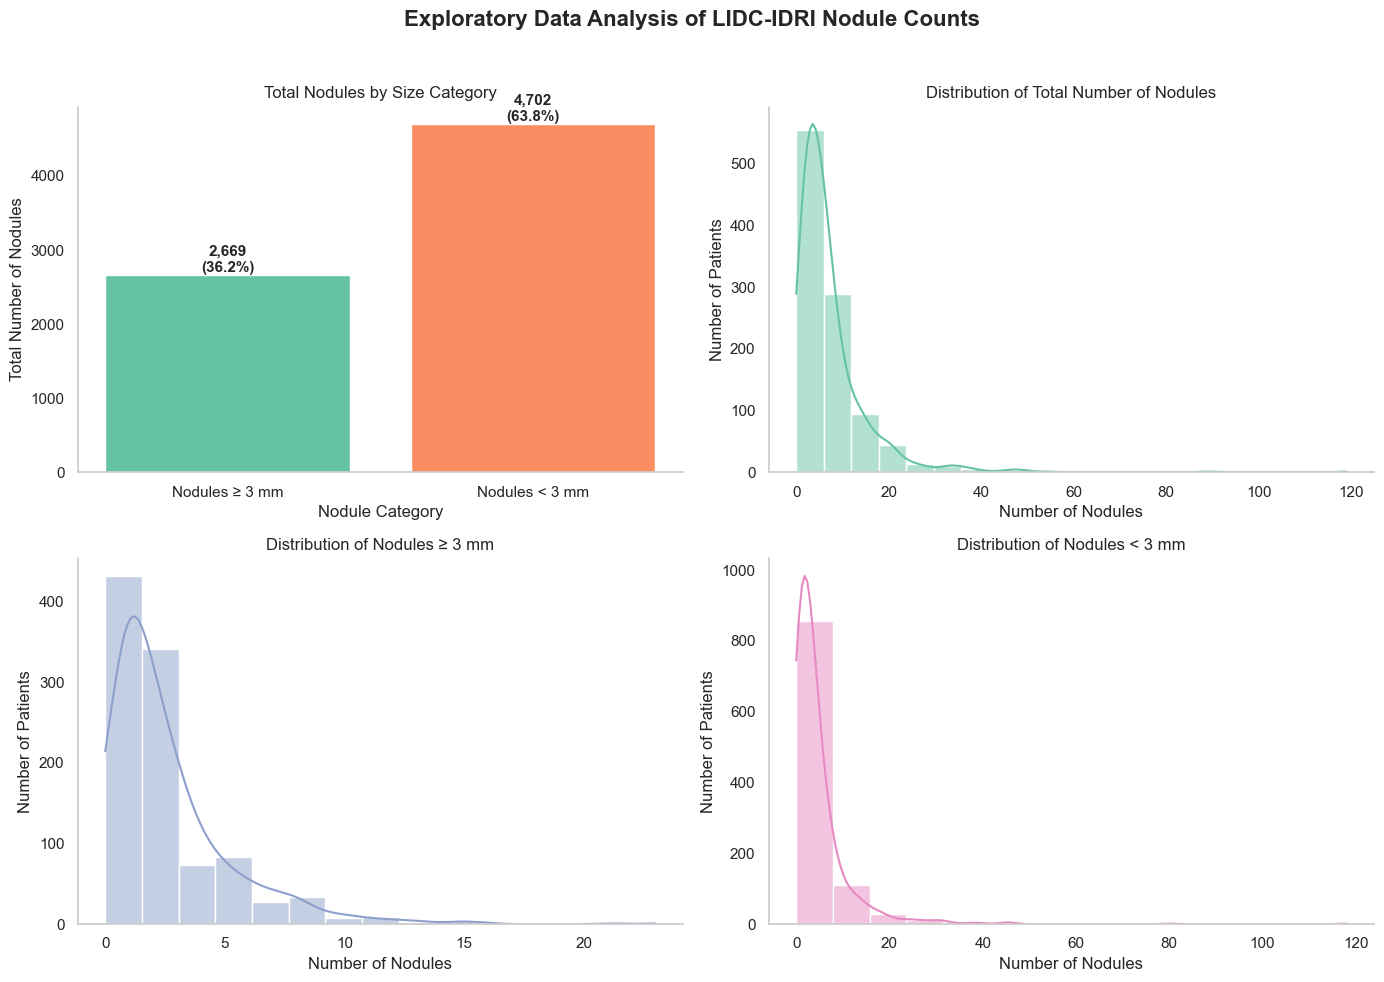

In [12]:
# Dashboard Layout
n_charts = 4
n_cols = 2
n_rows = math.ceil(n_charts / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 10)
)

fig.suptitle(
    "Exploratory Data Analysis of LIDC-IDRI Nodule Counts",
    fontsize=16,
    fontweight="bold"
)

axes = axes.flatten()

# Distribution of Total Number of Nodules
ax = axes[1]

sns.histplot(
    data=nodule_counts,
    x="total_number_of_nodules*",
    bins=20,
    kde=True,
    color=sns.color_palette("Set2")[0],
    ax=ax
)

ax.set_title("Distribution of Total Number of Nodules")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Total Nodules by Size Category
ax = axes[0]

large_nodules = nodule_counts["number_of_nodules_>=3mm**"].sum()
small_nodules = nodule_counts["number_of_nodules_<3mm***"].sum()

labels = ["Nodules ≥ 3 mm", "Nodules < 3 mm"]
counts = [large_nodules, small_nodules]

total_nodules = sum(counts)

bars = ax.bar(
    labels,
    counts,
    color=sns.color_palette("Set2")[:2]
)

ax.set_title("Total Nodules by Size Category")
ax.set_xlabel("Nodule Category")
ax.set_ylabel("Total Number of Nodules")

# Add count and percentage
for bar, value in zip(bars, counts):
    percentage = value / total_nodules * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

sns.despine(ax=ax)

# Distribution of Nodules ≥ 3 mm
ax = axes[2]

sns.histplot(
    data=nodule_counts,
    x="number_of_nodules_>=3mm**",
    bins=15,
    kde=True,
    color=sns.color_palette("Set2")[2],
    ax=ax
)

ax.set_title("Distribution of Nodules ≥ 3 mm")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Distribution of Nodules < 3 mm
ax = axes[3]

sns.histplot(
    data=nodule_counts,
    x="number_of_nodules_<3mm***",
    bins=15,
    kde=True,
    color=sns.color_palette("Set2")[3],
    ax=ax
)

ax.set_title("Distribution of Nodules < 3 mm")
ax.set_xlabel("Number of Nodules")
ax.set_ylabel("Number of Patients")

sns.despine(ax=ax)

# Final Layout
for ax in axes:
    ax.grid(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

- The original LIDC-IDRI dataset contains more nodules smaller than 3 mm (63.8%) than nodules measuring at least 3 mm (36.2%).
- The total number of nodules per patient is highly right-skewed, with most patients having only a few nodules.
- Most patients contain only one to three nodules measuring at least 3 mm, while patients with more large nodules are relatively uncommon.
- Most patients contain only a few nodules smaller than 3 mm, although a small number of patients have substantially more such nodules.

# Explore LIDC-IDRI Dataset

## Load Dataset

In [13]:
# Load All Scans
scans = pl.query(pl.Scan).all()
print(f"Total scan objects loaded: {len(scans)}")

Total scan objects loaded: 1018


## Total Studies and Unique Patient from LIDC-IDRI Dataset

In [16]:
# Extract patient ids
patient_ids = [scan.patient_id for scan in scans]

# Count total studies
total_studies = len(patient_ids)

# Get unique patient ids
unique_patients = sorted(set(patient_ids))
total_unique_patients = len(unique_patients)

# Count occurrences of each patient id
scan_count_per_patient = Counter(patient_ids)

# Create summary dataframe
summary_df = pd.DataFrame({
    "Metric": [
        "Total Studies",
        "Total Unique Patients"
    ],
    "Value": [
        total_studies,
        total_unique_patients
    ]
})

display(summary_df)

,Metric,Value
0,Total Studies,1018
1,Total Unique Patients,1010


## Check Patient with Multiple Studies

In [29]:
# Find duplicated patient ids automatically
duplicate_patients = {
    pid: count
    for pid, count in scan_count_per_patient.items()
    if count > 1
}

# Automatically get duplicated patient ids
duplicate_ids = list(duplicate_patients.keys())
study_uids = []

for pid in duplicate_ids:
    scans_pid = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()
    
    for i, scan in enumerate(scans_pid):
        study_uids.append(scan.study_instance_uid)

# Duplicate patient ids data
duplicate_ids_ct_df = nbia_digest_df[
    nbia_digest_df["study_instance_uid"].isin(study_uids)
]
duplicate_ids_ct_df = duplicate_ids_ct_df[["patient_id", "study_instance_uid", "modality", "series_description", "annotations_flag", "image_count"]]
display(duplicate_ids_ct_df)

,patient_id,study_instance_uid,modality,series_description,annotations_flag,image_count
234,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,CT,ThorRoutine 3.0 B31f,1.0,116
235,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,CT,ChestRoutine 3.0 B31f,NaN,127
263,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,CT,NaN,1.0,112
264,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,CT,ThoraxRoutine 3.0 B31s,NaN,111
556,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,CT,ThorRoutine 3.0 B31f,1.0,122
557,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,CT,NaN,1.0,117
572,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,CT,NaN,1.0,181
573,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,CT,NaN,1.0,292
594,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,CT,NaN,1.0,119
595,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,CT,ThoraxRoutine 3.0 B31s,1.0,121


## Duplicate Patient Study Analysis

In [33]:
# Store metadata for patients with multiple CT scans
duplicate_scan_info = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:
    scans = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()

    # Extract metadata from each CT scan
    for scan in scans:
        duplicate_scan_info.append({
            "patient_id": scan.patient_id,
            "study_uid": scan.study_instance_uid,
            "series_uid": scan.series_instance_uid,
            "slice_thickness": scan.slice_thickness,
            "pixel_spacing": scan.pixel_spacing,
        })

# Convert the collected metadata into a DataFrame
duplicate_scan_info_df = pd.DataFrame(duplicate_scan_info)

# Display duplicate scan metadata
display(duplicate_scan_info_df)

,patient_id,study_uid,series_uid,slice_thickness,pixel_spacing
0,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,1.3.6.1.4.1.14519.5.2.1.6279.6001.151647338241...,3.0,0.537109
1,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,1.3.6.1.4.1.14519.5.2.1.6279.6001.254176853278...,3.0,0.546875
2,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,1.3.6.1.4.1.14519.5.2.1.6279.6001.453946099750...,3.0,0.574219
3,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,1.3.6.1.4.1.14519.5.2.1.6279.6001.768856069922...,3.0,0.613000
4,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,1.3.6.1.4.1.14519.5.2.1.6279.6001.406508755509...,3.0,0.802734
5,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,1.3.6.1.4.1.14519.5.2.1.6279.6001.322682676064...,3.0,0.789000
6,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,1.3.6.1.4.1.14519.5.2.1.6279.6001.316900421002...,2.5,0.644531
7,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,1.3.6.1.4.1.14519.5.2.1.6279.6001.159996104466...,2.5,0.644531
8,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170344311940...,3.0,0.640000
9,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,1.3.6.1.4.1.14519.5.2.1.6279.6001.147979688121...,3.0,0.613281


In [34]:
# Summarize duplicate CT study information for each patient
summary = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:

    # Retrieve metadata for the current patient
    df = duplicate_scan_info_df[
        duplicate_scan_info_df["patient_id"] == pid
    ]

    # Count unique studies, series, and slice thickness values
    summary.append({
        "patient_id": pid,
        "n_studies": df["study_uid"].nunique(),
        "n_series": df["series_uid"].nunique(),
        "slice_thickness": df["slice_thickness"].nunique(),
    })

# Convert the summary into a DataFrame
summary_df = pd.DataFrame(summary)

# Display the summary
display(summary_df)

,patient_id,n_studies,n_series,slice_thickness
0,LIDC-IDRI-0132,2,2,1
1,LIDC-IDRI-0151,2,2,1
2,LIDC-IDRI-0315,2,2,1
3,LIDC-IDRI-0332,2,2,1
4,LIDC-IDRI-0355,2,2,1
5,LIDC-IDRI-0365,2,2,1
6,LIDC-IDRI-0442,2,2,1
7,LIDC-IDRI-0484,2,2,1


In [35]:
# Store annotation information for duplicate CT studies
results = []

# Iterate through duplicated patient IDs
for pid in duplicate_ids:
    scans = pl.query(pl.Scan).filter(
        pl.Scan.patient_id == pid
    ).all()

    # Count the number of annotations and annotation clusters for each CT study
    for scan in scans:
        results.append({
            "patient_id": scan.patient_id,
            "study_uid": scan.study_instance_uid,
            "annotations": len(scan.annotations),
            "clusters": len(scan.cluster_annotations())
        })

# Convert the collected information into a DataFrame
results_df = pd.DataFrame(results)

# Display the annotation summary
display(results_df)

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


,patient_id,study_uid,annotations,clusters
0,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,12,6
1,LIDC-IDRI-0132,1.3.6.1.4.1.14519.5.2.1.6279.6001.314138616411...,17,8
2,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275...,3,1
3,LIDC-IDRI-0151,1.3.6.1.4.1.14519.5.2.1.6279.6001.780121538270...,4,1
4,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.190722769298...,18,7
5,LIDC-IDRI-0315,1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509...,19,5
6,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927...,8,2
7,LIDC-IDRI-0332,1.3.6.1.4.1.14519.5.2.1.6279.6001.299122687641...,9,4
8,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753...,1,1
9,LIDC-IDRI-0355,1.3.6.1.4.1.14519.5.2.1.6279.6001.246541809203...,3,2


Eight patients in the LIDC-IDRI dataset have two CT studies with different Study Instance UIDs and Series Instance UIDs. The slice thickness is identical within each patient. One CT study should be selected for each patient to ensure a unique patient representation in the final dataset.

Study Selection Criteria
- Priority was given to the study with the largest number of nodule annotation clusters (len(scan.cluster_annotations())), as annotation clusters represent unique pulmonary nodules.
- If multiple studies contained the same number of annotation clusters, the study with the largest number of individual annotations (len(scan.annotations)) was selected.
- If both the number of annotation clusters and individual annotations were identical, the study with the largest number of image slices (image_count) was selected to retain the more complete CT volume.

In [36]:
excluded_study_uids = [
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102832118810712329678",  # LIDC-IDRI-0132
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.222444895275634974977432374937",  # LIDC-IDRI-0151
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.709924281509506265799179464374",  # LIDC-IDRI-0315
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.124508094927772723365648607398",  # LIDC-IDRI-0332
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.221138977753587043062153841454",  # LIDC-IDRI-0355
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.216207548522622026268886920069",  # LIDC-IDRI-0365
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.265657827498396379702226874113",  # LIDC-IDRI-0442
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.202012743926377385386645171009",  # LIDC-IDRI-0484
]

# LIDC-IDRI Studies Metadata Exploration

## DICOM Metadata Extraction

In [ ]:
# Helper Functions
def get_dicom_attr(dicom, attr, default=np.nan):
    """Safely retrieve a DICOM attribute."""
    return getattr(dicom, attr, default)


# Extract DICOM Metadata
study_metadata_list = []
failed_studies = []

scans = pl.query(pl.Scan).all()

for scan in tqdm(scans, desc="Processing CT studies"):
    try:
        dicom_images = scan.load_all_dicom_images()

        # Basic information
        first_dicom = dicom_images[0]
        middle_dicom = dicom_images[len(dicom_images) // 2]

        # Slice positions
        z_positions = sorted(
            float(dcm.ImagePositionPatient[2])
            for dcm in dicom_images
        )

        slice_spacing = (
            float(np.mean(np.diff(z_positions)))
            if len(z_positions) > 1
            else np.nan
        )

        scan_length = (
            float(max(z_positions) - min(z_positions))
            if len(z_positions) > 1
            else np.nan
        )

        # Convert CT volume to Hounsfield Unit (HU)
        volume = scan.to_volume()

        hu_min = float(np.min(volume))
        hu_max = float(np.max(volume))
        hu_mean = float(np.mean(volume))
        hu_std = float(np.std(volume))

        hu_p1 = float(np.percentile(volume, 1))
        hu_p5 = float(np.percentile(volume, 5))
        hu_p95 = float(np.percentile(volume, 95))
        hu_p99 = float(np.percentile(volume, 99))

        # Store metadata
        metadata = {

            # Identification
            "patient_id": scan.patient_id,
            "study_instance_uid": scan.study_instance_uid,
            "series_instance_uid": scan.series_instance_uid,

            # Image Geometry
            "rows": int(first_dicom.Rows),
            "columns": int(first_dicom.Columns),
            "num_slices": len(dicom_images),

            "pixel_spacing_x_mm":
                float(first_dicom.PixelSpacing[0]),

            "pixel_spacing_y_mm":
                float(first_dicom.PixelSpacing[1]),

            "slice_thickness_mm":
                float(get_dicom_attr(
                    middle_dicom,
                    "SliceThickness"
                )),

            "slice_spacing_mm":
                slice_spacing,

            "scan_length_mm":
                scan_length,

            # Intensity
            "rescale_slope":
                float(get_dicom_attr(
                    middle_dicom,
                    "RescaleSlope",
                    1.0
                )),

            "rescale_intercept":
                float(get_dicom_attr(
                    middle_dicom,
                    "RescaleIntercept",
                    0.0
                )),

            # HU Statistics
            "hu_min": hu_min,
            "hu_max": hu_max,
            "hu_mean": hu_mean,
            "hu_std": hu_std,
            "hu_p1": hu_p1,
            "hu_p5": hu_p5,
            "hu_p95": hu_p95,
            "hu_p99": hu_p99,

            # Reconstruction
            "convolution_kernel":
                get_dicom_attr(
                    middle_dicom,
                    "ConvolutionKernel"
                ),

            "reconstruction_diameter_mm":
                get_dicom_attr(
                    middle_dicom,
                    "ReconstructionDiameter"
                ),

            # Patient Orientation
            "patient_position":
                get_dicom_attr(
                    middle_dicom,
                    "PatientPosition"
                ),
        }

        study_metadata_list.append(metadata)

    except Exception as e:

        failed_studies.append({
            "patient_id": scan.patient_id,
            "study_instance_uid": scan.study_instance_uid,
            "error": str(e)
        })


# Convert to DataFrame
study_metadata_df = pd.DataFrame(study_metadata_list)

# Save CSV
output_file = (
    "../../dataset_sample/lidc_idri_metadata/dicom_metdata.csv"
)

study_metadata_df.to_csv(
    output_file,
    index=False
)

# Summary
print(f"Metadata saved successfully to: {output_file}")
print(f"Processed studies : {len(study_metadata_df)}")
print(f"Failed studies    : {len(failed_studies)}")

if failed_studies:
    failed_df = pd.DataFrame(failed_studies)
    display(failed_df.head())

Processing CT studies:   0%|          | 0/1018 [00:00<?, ?it/s]

Loading dicom files ... This may take a moment.


Processing CT studies:   1%|          | 12/1018 [00:01<01:47,  9.32it/s]

Loading dicom files ... This may take a moment.


Processing CT studies:   1%|▏         | 13/1018 [00:03<05:49,  2.87it/s]

...

Processing CT studies:   1%|▏         | 15/1018 [00:06<11:49,  1.41it/s]

Loading dicom files ... This may take a moment.


Processing CT studies: 100%|██████████| 1018/1018 [00:08<00:00, 123.84it/s]

Metadata saved successfully to: ../../dataset_sample/lidc_idri_metadata/dicom_metdata.csv
Processed studies : 5
Failed studies    : 1013


,patient_id,study_instance_uid,error
0,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,"Couldn't find DICOM files for Scan(id=1,patien..."
1,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.303241414168...,"Couldn't find DICOM files for Scan(id=2,patien..."
2,LIDC-IDRI-0079,1.3.6.1.4.1.14519.5.2.1.6279.6001.303921580531...,"Couldn't find DICOM files for Scan(id=3,patien..."
3,LIDC-IDRI-0101,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,"Couldn't find DICOM files for Scan(id=4,patien..."
4,LIDC-IDRI-0110,1.3.6.1.4.1.14519.5.2.1.6279.6001.924939006160...,"Couldn't find DICOM files for Scan(id=5,patien..."


In [ ]:
study_metadata_list = []
failed_studies = []

for scan in tqdm(scans, desc="Processing studies"):
    try:
        # Suppress PyLIDC loading message
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull):
                dicom_images = scan.load_all_dicom_images()

        middle_idx = len(dicom_images) // 2
        middle_dicom = dicom_images[middle_idx]

        z_positions = sorted(
            float(dcm.ImagePositionPatient[2])
            for dcm in dicom_images
        )

        slice_spacing_mm = np.mean(np.diff(z_positions))

        study_metadata = {
            "study_instance_uid": scan.study_instance_uid,
            "num_slices": len(dicom_images),
            "slice_thickness_mm": float(middle_dicom.SliceThickness),
            "slice_spacing_mm": float(slice_spacing_mm),
            "pixel_spacing_x_mm": float(middle_dicom.PixelSpacing[0]),
            "pixel_spacing_y_mm": float(middle_dicom.PixelSpacing[1]),
        }

        study_metadata_list.append(study_metadata)

    except Exception as e:
        print(
            f"\n[ERROR] Failed to process study "
            f"{scan.study_instance_uid}: {e}"
        )

        failed_studies.append({
            "study_instance_uid": scan.study_instance_uid,
            "error": str(e)
        })

# Convert to DataFrame
study_metadata_df = pd.DataFrame(study_metadata_list)

# Save metadata
output_file = "../dataset/lidc_idri_metadata/lidc_idri_study_metadata.csv"
study_metadata_df.to_csv(output_file, index=False)

print(f"\nMetadata saved successfully to '{output_file}'")
print(f"Processed studies : {len(study_metadata_df)}")
print(f"Failed studies    : {len(failed_studies)}")

In [ ]:
study_metadata_df = pd.read_csv("../dataset/lidc_idri_metadata/lidc_idri_study_metadata.csv", index_col=False)
study_metadata_df.describe()

## Distribution of Number of Slices per Study

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["num_slices"],
    bins=30,
    kde=True
)

plt.axvline(
    study_metadata_df["num_slices"].mean(),
    linestyle="--",
    label="Mean",
    color="g"
)

plt.axvline(
    study_metadata_df["num_slices"].median(),
    linestyle="-.",
    label="Median",
    color="r"
)

plt.title("Distribution of Number of Slices per Study")
plt.xlabel("Number of Slices")
plt.ylabel("Count")
plt.legend()

plt.show()

## Ditribution of Slice Thickness

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["slice_thickness_mm"],
    bins="auto",
    kde=True
)

plt.title("Distribution of Slice Thickness")
plt.xlabel("Slice Thickness (mm)")
plt.ylabel("Count")

plt.show()

## Ditribution of Slice Spacing

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    study_metadata_df["slice_spacing_mm"],
    bins="auto",
    kde=True
)

plt.title("Distribution of Slice Spacing")
plt.xlabel("Slice Spacing (mm)")
plt.ylabel("Count")

plt.show()

## Boxplot Visualization

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=study_metadata_df["num_slices"], ax=axes[0])
axes[0].set_title("Number of Slices")

sns.boxplot(y=study_metadata_df["slice_thickness_mm"], ax=axes[1])
axes[1].set_title("Slice Thickness")

sns.boxplot(y=study_metadata_df["slice_spacing_mm"], ax=axes[2])
axes[2].set_title("Slice Spacing")

plt.tight_layout()
plt.show()

* The LIDC-IDRI dataset contains **1018 total studies**, which represent all `Scan` objects returned by PyLIDC.
* The dataset contains **1010 unique patients**, identified using unique `patient_id` values.
* There are **8 patients** that have more than one CT scan/study in the dataset:
  * `LIDC-IDRI-0132`
  * `LIDC-IDRI-0151`
  * `LIDC-IDRI-0315`
  * `LIDC-IDRI-0332`
  * `LIDC-IDRI-0355`
  * `LIDC-IDRI-0365`
  * `LIDC-IDRI-0442`
  * `LIDC-IDRI-0484`
* These duplicated patient IDs are not dataset errors; they indicate that the same patient has multiple CT scan studies.
* A **Study Instance UID** uniquely identifies one DICOM study or examination performed on a patient.
* A **Series Instance UID** uniquely identifies one image series within a study.
* The dataset contains a total of **243,945 CT slices** across all studies.
* The minimum number of slices in one study is **65 slices**, while the maximum reaches **764 slices**, showing a large variation in CT volume depth.
* The average number of slices per study is approximately **239.63 slices**, with a median of **203.50 slices**.
* The standard deviation is relatively high (**133.39 slices**), indicating substantial variability in scan length between studies.
* Based on the histogram distribution, most studies are concentrated around **100–300 slices**, with several studies containing significantly larger numbers of slices.
* The slice distribution is positively skewed (right-skewed), meaning a small number of studies contain very large CT volumes compared to the majority of the dataset.


# Clustering

In [ ]:
# ============================================
# SET CSV PATH
# ============================================

csv_path = "../dataset/lidc_idri_metadata/lidc_nodule_clusters.csv"

In [ ]:
# ============================================
# CHECK WHETHER CLUSTER CSV ALREADY EXISTS
# ============================================

if os.path.exists(csv_path):

    print("Cluster CSV already exists.")
    print("Loading precomputed cluster metadata...\n")

    # Load existing CSV
    cluster_df = pd.read_csv(csv_path)

else:

    print("Cluster CSV not found.")
    print("Running annotation clustering...\n")

    # ============================================
    # LOAD ALL SCANS
    # ============================================

    scans = pl.query(pl.Scan).all()

    # ============================================
    # BUILD CLUSTER METADATA
    # ============================================

    cluster_rows = []

    # tqdm progress bar
    for scan_idx, scan in enumerate(
        tqdm(scans, desc="Clustering scans")
    ):

        # Cluster annotations for current scan
        clusters = scan.cluster_annotations()

        for nodule_idx, cluster in enumerate(clusters):

            # Annotation IDs
            annotation_ids = [ann.id for ann in cluster]

            # Malignancy features
            malignancies = [ann.malignancy for ann in cluster]

            # Geometric features
            diameters = [ann.diameter for ann in cluster]
            volumes = [ann.volume for ann in cluster]
            surface_areas = [ann.surface_area for ann in cluster]

            # Semantic features
            subtleties = [ann.subtlety for ann in cluster]
            textures = [ann.texture for ann in cluster]
            spiculations = [ann.spiculation for ann in cluster]
            lobulations = [ann.lobulation for ann in cluster]

            # Store cluster information
            cluster_rows.append({

                # Scan information
                "patient_id": scan.patient_id,
                "study_instance_uid": scan.study_instance_uid,
                "series_instance_uid": scan.series_instance_uid,

                # Scan metadata
                "slice_thickness": scan.slice_thickness,
                "pixel_spacing": scan.pixel_spacing,
                "num_slices": len(scan.slice_zvals),
                "contrast_used": scan.contrast_used,
                "is_from_initial": scan.is_from_initial,

                # Nodule information
                "nodule_idx": nodule_idx,
                "num_annotations": len(cluster),
                "annotation_ids": annotation_ids,

                # Malignancy
                "malignancy_mean": np.mean(malignancies),
                "malignancy_std": np.std(malignancies),

                # Geometric features
                "diameter_mean": np.mean(diameters),
                "volume_mean": np.mean(volumes),
                "surface_area_mean": np.mean(surface_areas),

                # Semantic features
                "subtlety_mean": np.mean(subtleties),
                "texture_mean": np.mean(textures),
                "spiculation_mean": np.mean(spiculations),
                "lobulation_mean": np.mean(lobulations)
            })

    # ============================================
    # CONVERT TO DATAFRAME
    # ============================================

    cluster_df = pd.DataFrame(cluster_rows)

    # ============================================
    # SAVE CSV
    # ============================================

    cluster_df.to_csv(
        csv_path,
        index=False
    )

    print(f"\nCluster metadata saved to: {csv_path}")

In [ ]:
# ============================================
# DISPLAY RESULT
# ============================================

cluster_df = pd.read_csv("../dataset/lidc_idri_metadata/lidc_nodule_clusters.csv")
print(f"\nTotal nodules: {len(cluster_df)}")

cluster_df.head()

In [ ]:
# ============================================
# DESCRIPTIVE STATISTICS OF CLUSTER METADATA
# ============================================
cluster_df.describe()

## Distribution of Num Annotation per Cluster

In [ ]:
# ============================================
# PLOT DISTRIBUTION OF NUM ANNOTATIONS PER NODULE
# ============================================

# Count frequency of each annotation count
annotation_counts = (
    cluster_df["num_annotations"]
    .value_counts()
    .sort_index()
    .reset_index()
)

annotation_counts.columns = [
    "num_annotations",
    "num_nodules"
]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=annotation_counts,
    x="num_annotations",
    y="num_nodules",
    color="steelblue"
)

# Add value labels above bars
for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.xlabel("Number of Annotations per Nodule")
plt.ylabel("Number of Nodules")
plt.title("Distribution of Annotations per Nodule")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Distribution of Diameter Nodules

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    cluster_df["diameter_mean"],
    bins=30,
    kde=True
)

plt.xlabel("Number of Nodules")
plt.ylabel("Nodules Diameter (Mean)")
plt.title("Distribution of Nodules Diameter")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Diameter VS Number of Annotations

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="num_annotations",
    y="diameter_mean",
    data=cluster_df
)

plt.xlabel("Number of Annoatations")
plt.ylabel("Nodules Diameter (Mean)")
plt.title("Nodules Diameter VS Number of Annotations")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Malignancy

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    cluster_df["malignancy_mean"],
    bins=np.arange(1, 7)-0.5
)

plt.xlabel("Malignancy Level (Mean)")
plt.ylabel("Num of Nodules")
plt.title("Distribution of Nodules Malignancy (Mean)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

## Diameter VS Malignancy

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cluster_df,
    x="diameter_mean",
    y="malignancy_mean"
)

plt.xlabel("Nodules Diameter (Mean)")
plt.ylabel("Malignancy Level (Mean)")
plt.title("Nodules Diameter (Mean) vs Malignancy Level (Mean)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [ ]:
features = [
    "diameter_mean",
    "malignancy_mean",
    "subtlety_mean",
    "texture_mean",
    "spiculation_mean",
    "lobulation_mean"
]

corr = cluster_df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

# Sampling

In [ ]:
print(f"Initial clusters: {len(cluster_df)}")

In [ ]:
diameter_filtered_df = cluster_df[
    cluster_df["diameter_mean"].between(3, 30)
].copy()

print(f"After diameter filtering: {len(diameter_filtered_df)}")

In [ ]:
annotator_filtered_df = diameter_filtered_df[
    diameter_filtered_df["num_annotations"] >= 3
].copy()

print(f"After radiologist filtering: {len(annotator_filtered_df)}")

In [ ]:
selected_df = annotator_filtered_df.copy()

selected_df["class_label"] = np.where(
    selected_df["malignancy_mean"] <= 2.5,
    "benign",
    np.where(
        selected_df["malignancy_mean"] >= 3.5,
        "malignant",
        "ambiguous"
    )
)

selected_df = selected_df[
    selected_df["class_label"] != "ambiguous"
].copy()

selected_df.to_csv("../dataset/lidc_idri_metadata/selected_nodule.csv", index=False)
print(f"Final selected nodules: {len(selected_df)}")

In [ ]:
selected_df["class_label"].value_counts()

In [ ]:
selection_summary = {
    "Initial clusters": len(cluster_df),
    "Diameter 3-30 mm": len(diameter_filtered_df),
    "≥3 annotations": len(annotator_filtered_df),
    "Final selected": len(selected_df)
}

print(pd.Series(selection_summary))